In [6]:
# Gõ dòng này vào cell đầu tiên và bấm Run (Shift + Enter)
get_ipython().run_line_magic('run', '../_setup.py')

In [7]:
import tsfeatures as tsf
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from pathlib import Path

mpl.rcParams['axes.prop_cycle'] = cycler(color=["#D55F03", "#569CC6", "#13A076", "#CC79A7"])

In [8]:
BASE_DIR = Path.cwd().parent.parent
DATA_DIR = BASE_DIR / "data"
print(DATA_DIR)

d:\Documents\GitHub\-Time-Series-Analysis-and-Forecasting-methods-\data


### 1. Write a function to compute the mean and standard deviation of a time series, and apply it to the `PBS` data. Plot the series with the highest mean, and the series with the lowest standard deviation.

,ATC2,mean,std
0,A01,2.848e+04,3.351e+04
1,A02,6.902e+06,7.609e+06
2,A03,2.068e+05,2.858e+05
3,A04,2.341e+05,1.871e+05
4,A05,7.539e+04,7.288e+04


ATC2 with highest mean: C10
ATC2 with lowest standard deviation: R


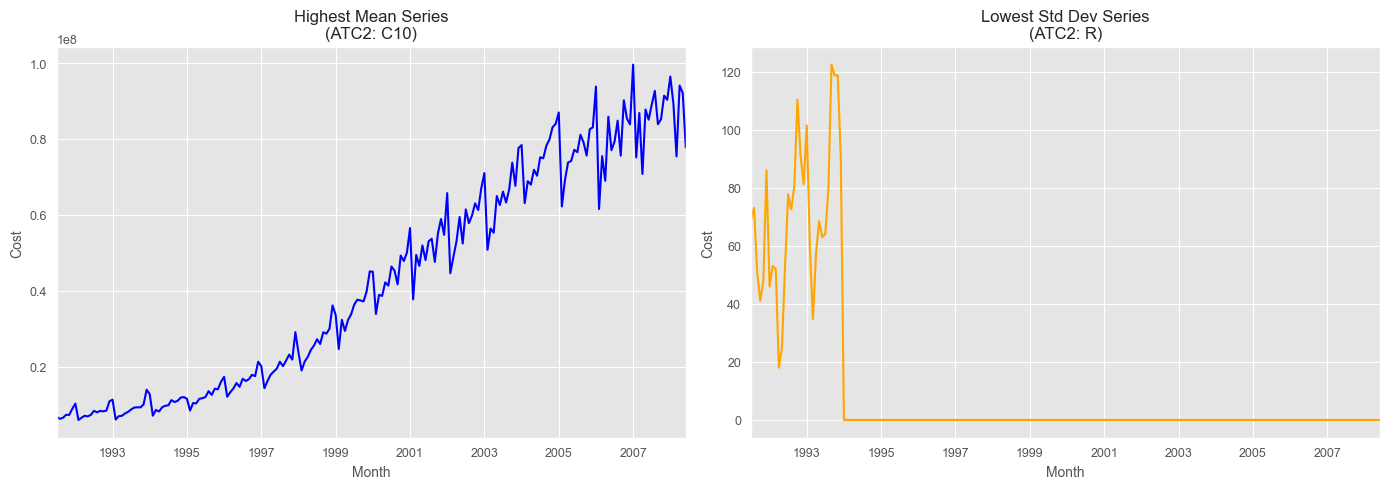

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

def get_ts_stats(df, target_col, unique_col):
    stats = df.groupby(unique_col)[target_col].agg(['mean', 'std']).reset_index()
    return stats

pbs = pd.read_csv(DATA_DIR / "pbs.csv", parse_dates=['Month'])
pbs_stats = get_ts_stats(pbs, target_col='Cost', unique_col='ATC2')
display(pbs_stats.head())


highest_mean_id = pbs_stats.loc[pbs_stats['mean'].idxmax(), 'ATC2']
lowest_std_id = pbs_stats.loc[pbs_stats['std'].idxmin(), 'ATC2']

print(f"ATC2 with highest mean: {highest_mean_id}")
print(f"ATC2 with lowest standard deviation: {lowest_std_id}")

high_mean_df = pbs[pbs['ATC2'] == highest_mean_id]
low_std_df = pbs[pbs['ATC2'] == lowest_std_id]


plt.figure(figsize=(14, 5))

# Plot 1: Highest Mean
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
high_mean_df.groupby('Month')['Cost'].sum().plot(color='blue')
plt.title(f'Highest Mean Series\n(ATC2: {highest_mean_id})')
plt.ylabel('Cost')

# Plot 2: Lowest STD
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
low_std_df.groupby('Month')['Cost'].sum().plot(color='orange')
plt.title(f'Lowest Std Dev Series\n(ATC2: {lowest_std_id})')
plt.ylabel('Cost')

plt.tight_layout()
plt.show()


### 2. Use `sns.pairplot()` to look at the relationships between the STL-based features for the holiday series in the `tourism` data. Change `seasonal_peak_year` and `seasonal_trough_year` to factors, as shown in Figure 4.3. Which is the peak quarter for holidays in each state?

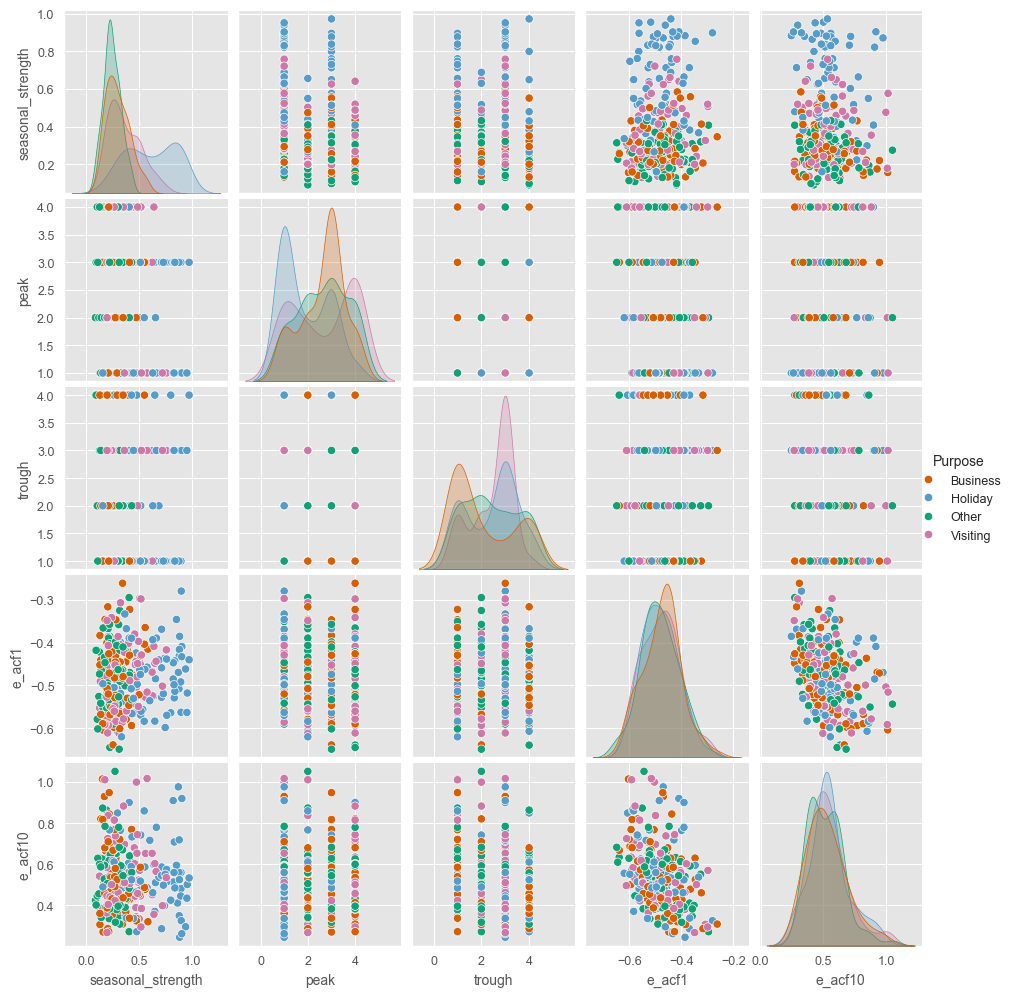

In [19]:
tourism = (
    pd.read_csv(DATA_DIR / "tourism.csv", parse_dates = ['ds'])
    .assign(unique_id = lambda df: df['Region'] + "-" + df['State'] + "-" + df['Purpose'])
)

stl_feat = tsf.tsfeatures(tourism, freq=4, features=[tsf.stl_features])
stl_feat.head(10)

seasonal_feat = stl_feat[
    ["unique_id", "seasonal_strength", "peak", "trough",
     "e_acf1", "e_acf10"]
]
df = (
    seasonal_feat["unique_id"].str.split("-", expand=True)
    .rename(columns={0: "region", 1: "state", 2: "Purpose"})
    .join(seasonal_feat)
)
g = sns.pairplot(df, hue="Purpose")
g.fig.set_size_inches(10, 10)
plt.show()

### 3. Use a feature-based approach to look for outlying series in the `PBS` data. What is unusual about the series you identify as “outliers”?

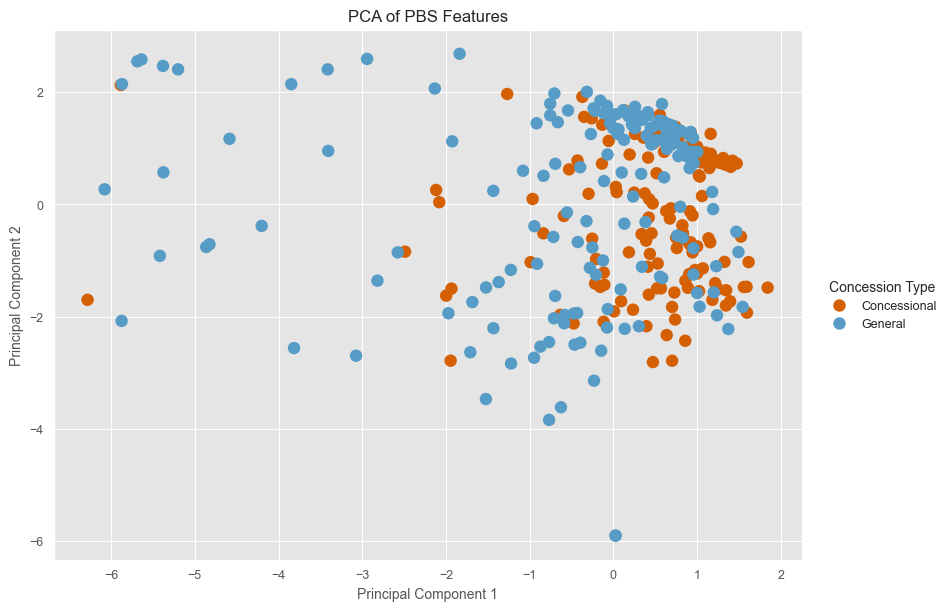

Top 3 Outliers tìm thấy: ['General_Co-payments_R_R', 'General_Co-payments_S_S', 'General_Safety net_V_V01']


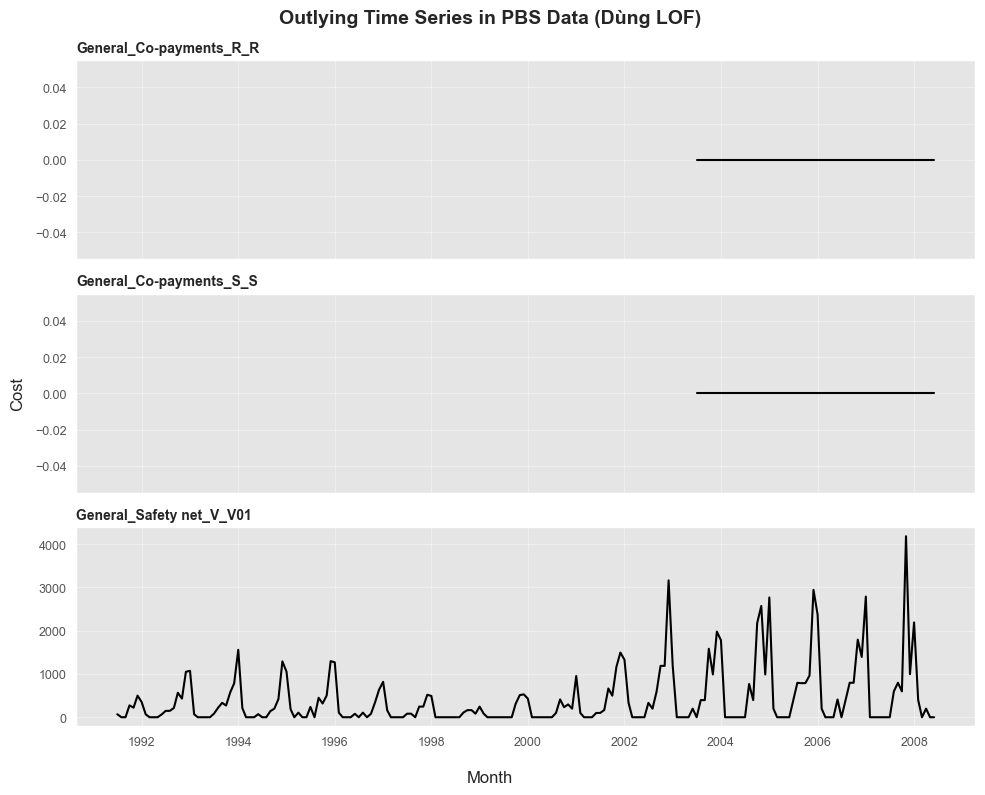

In [ ]:
# ---------------------------------------------------------
# Bước 1: Chuẩn bị dữ liệu PBS
# ---------------------------------------------------------
pbs = pd.read_csv(DATA_DIR / "pbs.csv", parse_dates=['Month'])

pbs['unique_id'] = pbs['Concession'] + "_" + pbs['Type'] + "_" + pbs['ATC1'] + "_" + pbs['ATC2']
pbs_ts = pbs.groupby(['unique_id', 'Month'])['Cost'].sum().reset_index()
pbs_ts = pbs_ts.rename(columns={'Month': 'ds', 'Cost': 'y'})

# ---------------------------------------------------------
# Bước 2: Trích xuất đặc trưng (Feature Extraction)
# ---------------------------------------------------------
features = tsfeatures(pbs_ts, freq=12)

# ---------------------------------------------------------
# Bước 3: Giảm chiều dữ liệu bằng PCA (ĐÃ SỬA LỖI)
# ---------------------------------------------------------
features_numeric = features.drop(columns=['unique_id']).dropna(axis=1)
features_scaled = StandardScaler().fit_transform(features_numeric)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(features_scaled)

# TẠO PCA_DF ĐÚNG CÁCH (Ghép với tập features, KHÔNG ghép với pbs_ts)
pca_df = pd.DataFrame(data=pca_result, columns=["PC1", "PC2"])
pca_df['unique_id'] = features['unique_id'].values

# Trích xuất 'Concession' từ unique_id (phần đầu tiên trước dấu '_') để làm màu phân loại
pca_df['Concession_Type'] = pca_df['unique_id'].apply(lambda x: x.split('_')[0])

# Vẽ biểu đồ PCA
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    x="PC1", y="PC2", s=80,
    hue="Concession_Type", # Đổi từ 'purpose' sang 'Concession_Type'
    edgecolor="none", data=pca_df, ax=ax
)

ax.set(
    title="PCA of PBS Features",
    xlabel="Principal Component 1",
    ylabel="Principal Component 2",
)
ax.get_legend().remove()
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels,
    title="Concession Type", loc="center left", frameon=False,
    bbox_to_anchor=(1.02, .5), borderaxespad=0)
plt.show()

# ---------------------------------------------------------
# Bước 4: Chấm điểm dị biệt bằng Local Outlier Factor (LOF)
# ---------------------------------------------------------
lof = LocalOutlierFactor(n_neighbors=10).fit(pca_df[["PC1", "PC2"]])
res = pca_df.assign(score=lof.negative_outlier_factor_)

selected_ids = res.sort_values("score")["unique_id"].head(3)
print(f"Top 3 Outliers tìm thấy: {selected_ids.tolist()}")

# ---------------------------------------------------------
# Bước 5: Vẽ biểu đồ các Outliers
# ---------------------------------------------------------
fig, axs = plt.subplots(3, figsize=(10, 8), sharex=True)

for (ax, unique_id) in zip(axs, selected_ids):
    df = pbs_ts.loc[lambda x: x["unique_id"] == unique_id]
    
    ax.plot(df["ds"], df["y"], color="k")
    ax.set_title(unique_id, loc="left", size="medium", fontweight="bold")
    ax.grid(True, alpha=0.4)

fig.suptitle("Outlying Time Series in PBS Data (Dùng LOF)", fontsize=14, fontweight="bold")
fig.supylabel("Cost")
fig.supxlabel("Month")

plt.tight_layout()
plt.show()